In [ ]:
!pip install pysr

In [ ]:
import pandas as pd

df = pd.read_csv("auto_mpg.csv")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin   mpg  
0       1  18.0  
1       1  15.0  
2       1  18.0  
3       1  16.0  
4       1  17.0  

Shape: (392, 8)

Columns: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']


In [ ]:
X = df.drop(columns=["mpg"])
y = df["mpg"]
print(X.head)

<bound method NDFrame.head of      displacement  cylinders  horsepower  weight  acceleration  model_year  \
0           307.0          8       130.0    3504          12.0          70   
1           350.0          8       165.0    3693          11.5          70   
2           318.0          8       150.0    3436          11.0          70   
3           304.0          8       150.0    3433          12.0          70   
4           302.0          8       140.0    3449          10.5          70   
..            ...        ...         ...     ...           ...         ...   
387         140.0          4        86.0    2790          15.6          82   
388          97.0          4        52.0    2130          24.6          82   
389         135.0          4        84.0    2295          11.6          82   
390         120.0          4        79.0    2625          18.6          82   
391         119.0          4        82.0    2720          19.4          82   

     origin  
0         1  
1    

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42 #ensure u get the same split everytime
)

In [ ]:
print("X training shape:", X_train.shape)
print("X testing shape:", X_test.shape)
print("y training shape:", y_train.shape)
print("y testing shape:", y_test.shape)

X training shape: (313, 7)
X testing shape: (79, 7)
y training shape: (313,)
y testing shape: (79,)


In [ ]:
from pysr import PySRRegressor
#perform 40 rounds of envo;ving and improve the equation
    #operating two values such as x1 + x2
model = PySRRegressor(
    niterations=150,
    binary_operators = [
        "+",
        "-",
        "*",
        "/"
    ],
    #apply to one value
    unary_operators= [
        "square",
        "sqrt"
    ],
    maxsize = 30, #prevent the model to become ridiculous complicated
    model_selection="best",
    random_state=42, #experiment reproducible
    deterministic=True, #requests repeatable result
    parallelism="serial"
)

In [ ]:
model.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    variable_names=X.columns.tolist()
)

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          23.598633   
	1         0.621679                                 65372.867 / weight   
	2         0.182547                   (model_year * 855.3985) / weight   
	3   >>>>  0.144923   ((model_year + -46.281776) * 2149.9915) / weight   
	4         0.012254  ((model_year + -47.14129) / (weight - -228.470...   
	5         0.004409  sqrt(origin) + (((model_year + -48.08962) / we...   
	6         0.035693  ((model_year + -44.388947) * 325.6359) / (hors...   
	7         0.013776  (((model_year + -46.72296) / (horsepower + (we...   
	8         0.008320  (((model_year + -46.190895) * 327.40363) / (ho...   
	9         0.014700  ((model_year + -48.57722) * (327.48932 / (hors...   
	10        0.002185  (((model_year + -47.220173) * 327.34714) / ((w...   
	11        0.006823  (((model_year + -48.639877) * 524.9432) / ((ho...   
	12        0.000226  (origin + ((model_year + (model_year + -98.157...   
	13        0.038331  (origin * 3.02566) + ((((model_year + -102.296...   
	14        0.002196  ((((model_year + (model_year + -100.51098)) * ...   
	15        0.002349  (origin * 4.149269) + ((((model_year + (model_...   
	16        0.000256  (((((model_year + (model_year + -100.61752)) *...   
	17        0.000217  (((((model_year + (model_year + -100.84715)) /...   
	18        0.000027  ((((((model_year + model_year) + -100.84715) /...   
	
	         loss  complexity  
	0   63.099697           1  
	1   18.198856           3  
	2   12.632400           5  
	3    9.453813           7  
	4    9.224927           9  
	5    9.184341          10  
	6    8.862306          11  
	7    8.621468          13  
	8    8.550035          14  
	9    8.425269          15  
	10   8.406882          16  
	11   8.349718          17  
	12   8.345943          19  
	13   8.032092          20  
	14   7.996900          22  
	15   7.959423          24  
	16   7.955346          26  
	17   7.951892          28  
	18   7.951462          30  
]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test.to_numpy())
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Selected equation:")
print(model.sympy())

print("\nTest MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R²:", r2)



Selected equation:
(model_year - 46.281776)*2149.9915/weight

Test MSE: 7.5595587228514205
Test RMSE: 2.749465170328844
Test MAE: 2.055022307799312
Test R²: 0.8518912159109694


In [ ]:
model.equations_.to_csv(
    "auto_mpg_pysr_equations.csv"
)

In [ ]:
auto_results = pd.DataFrame({
    "Actual_MPG": y_test.to_numpy(),
    "Predicted_MPG": y_pred,
    "Absolute_Error": abs(y_test.to_numpy() - y_pred)
}
)
auto_results.to_csv(
    "auto_mpg_pysr_predictions.csv",
    index=False

)
auto_metrics = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R_squared"],
    "Value": [
        mse,
        rmse,
        mae,
        r2
    ]
}
)
auto_metrics.to_csv(
    "auto_mpg_pysr_metrics.csv",
    index=False
)

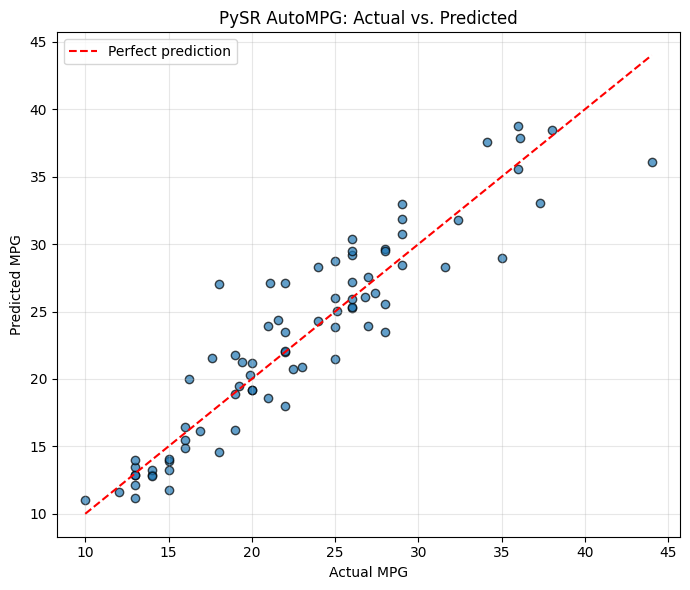

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    edgecolors="black"
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("PySR AutoMPG: Actual vs. Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "auto_mpg_pysr_actual_vs_predicted.png",
    dpi=300
)

plt.show()

# concrete dataset

In [ ]:
concrete_df = pd.read_csv("concrete.csv")

print(concrete_df.head())
print("\nShape:", concrete_df.shape)
print("\nColumns:", concrete_df.columns.tolist())
print("\nMissing values:", concrete_df.isna().sum().sum())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Concrete compressive strength  
0            1040.0           676.0   28                          79.99  
1            1055.0           676.0   28                          61.89  
2             932.0           594.0  270                          40.27  
3             932.0           594.0  365                          41.05  
4             978.4           825.5  360                          44.30  

Shape: (1030, 9)

Columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concre

In [ ]:
concrete_df.columns = [
    "cement",
    "slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
    "strength"
]
print(concrete_df.head())

   cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  \
0   540.0    0.0      0.0  162.0               2.5            1040.0   
1   540.0    0.0      0.0  162.0               2.5            1055.0   
2   332.5  142.5      0.0  228.0               0.0             932.0   
3   332.5  142.5      0.0  228.0               0.0             932.0   
4   198.6  132.4      0.0  192.0               0.0             978.4   

   fine_aggregate  age  strength  
0           676.0   28     79.99  
1           676.0   28     61.89  
2           594.0  270     40.27  
3           594.0  365     41.05  
4           825.5  360     44.30  


In [ ]:
concrete_X = concrete_df.drop(columns=["strength"])
concrete_y = concrete_df["strength"]
print(X.head)

<bound method NDFrame.head of       cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  \
0      540.0    0.0      0.0  162.0               2.5            1040.0   
1      540.0    0.0      0.0  162.0               2.5            1055.0   
2      332.5  142.5      0.0  228.0               0.0             932.0   
3      332.5  142.5      0.0  228.0               0.0             932.0   
4      198.6  132.4      0.0  192.0               0.0             978.4   
...      ...    ...      ...    ...               ...               ...   
1025   276.4  116.0     90.3  179.6               8.9             870.1   
1026   322.2    0.0    115.6  196.0              10.4             817.9   
1027   148.5  139.4    108.6  192.7               6.1             892.4   
1028   159.1  186.7      0.0  175.6              11.3             989.6   
1029   260.9  100.5     78.3  200.6               8.6             864.5   

      fine_aggregate  age  
0              676.0   28  
1            

In [ ]:
concrete_X_train, concrete_X_test, concrete_y_train, concrete_y_test = (
    train_test_split(
        concrete_X,
        concrete_y,
        test_size=0.20,
        random_state=42
    )
)
print("Training inputs:", concrete_X_train.shape)
print("Testing inputs:", concrete_X_test.shape)
print("Training targets:", concrete_y_train.shape)
print("Testing targets:", concrete_y_test.shape)

Training inputs: (824, 8)
Testing inputs: (206, 8)
Training targets: (824,)
Testing targets: (206,)


In [ ]:
concrete_model = PySRRegressor(
    niterations=300,
    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],
    unary_operators=[
        "square",
        "sqrt",
        "log"
    ],
    populations=20,
    population_size=50,
    maxsize=40,
    model_selection="best",
    random_state=42,
    parallelism="multithreading" #multi CPU workers at the same time
)

In [ ]:
concrete_pred = concrete_model.fit(
    concrete_X_train.to_numpy(),
    concrete_y_train.to_numpy(),
    variable_names = concrete_X.columns.tolist()
)
concrete_pred

/usr/local/lib/python3.13/dist-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          35.857937   
	1         0.088712                                cement * 0.12042955   
	2         0.119931                               log(age) * 10.920152   
	3         0.242775                           sqrt(cement * sqrt(age))   
	4         0.088435                    sqrt(log(square(age)) * cement)   
	5         0.288274         superplasticizer + sqrt(cement * log(age))   
	6         0.001720  sqrt((sqrt(superplasticizer) + log(age)) * cem...   
	7         0.079894  superplasticizer + sqrt(log(age) * (slag + cem...   
	8         0.005132  sqrt((cement * log(age)) * log(superplasticize...   
	9         0.119049  sqrt((log(age) * cement) * sqrt(sqrt(superplas...   
	10        0.069550  sqrt(((log(age) * cement) - fly_ash) * log(sup...   
	11        0.100585  sqrt(log(age) * (slag + (cement * 2.2472832)))...   
	12        0.120781  sqrt(((slag + (cement * log(superplasticizer +...   
	13        0.017024  sqrt(((slag + -244.07164) + (cement * log(supe...   
	14  >>>>  0.093318  (((square(log(cement)) * 2.0102994) + (log(age...   
	15        0.021422  (((water * -0.2818449) + (log(cement) * 24.517...   
	16        0.008133  ((log(age) * 8.639222) + square((log(cement) *...   
	17        0.027603  (log(cement) * 24.826647) + (((water * -0.2589...   
	18        0.036089  ((sqrt(slag) + (log(age) * 8.535521)) + (log(c...   
	19        0.034918  (((water * -0.12647663) + (square(log(cement) ...   
	20        0.066742  (sqrt(slag) + ((water * -0.20222154) + -33.065...   
	21        0.000840  (sqrt(slag - -0.36839765) + (log(age) * (sqrt(...   
	22        0.024937  (((water * -0.17656381) + square(log(cement) *...   
	23        0.006919  sqrt(slag) + ((square(log(cement) * log(cement...   
	24        0.005450  (water * -0.18264884) + ((((log(age) * 7.14111...   
	25        0.005231  ((log(age) * ((sqrt(sqrt(superplasticizer)) * ...   
	26        0.001146  (square(log(cement) * log(log(sqrt(cement)))) ...   
	27        0.011996  ((((sqrt(age * sqrt(sqrt(sqrt(superplasticizer...   
	28        0.004982  (((sqrt(sqrt(sqrt(sqrt(superplasticizer))) * a...   
	29        0.001727  ((((log(age) * 5.6016493) + (water * -0.158384...   
	30        0.001808  ((water * -0.1609333) + ((log(age) * 5.579593)...   
	31        0.009602  sqrt(age * sqrt(sqrt(sqrt(superplasticizer))))...   
	32        0.006016  sqrt(age * sqrt(sqrt(sqrt(sqrt(superplasticize...   
	
	          loss  complexity  
	0   284.086330           1  
	1   237.900920           3  
	2   211.013700           4  
	3   165.529300           5  
	4   151.519360           6  
	5   113.572250           7  
	6   113.377020           8  
	7   104.671326           9  
	8   104.135544          10  
	9    92.447845          11  
	10   86.236560          12  
	11   77.984406          13  
	12   69.111940          14  
	13   66.798460          16  
	14   60.846992          17  
	15   59.557407          18  
	16   59.075020          19  
	17   57.466682          20  
	18   55.429768          21  
	19   53.527700          22  
	20   50.071760          23  
	21   49.987682          25  
	22   48.756557          26  
	23   48.420383          27  
	24   47.895480          29  
	25   47.149765          32  
	26   47.041860          34  
	27   46.480940          35  
	28   46.249928          36  
	29   46.170124          37  
	30   46.086716          38  
	31   45.646294          39  
	32   45.372517          40  
]

In [ ]:
accuracy_index = concrete_pred.equations_["loss"].idxmin()

accuracy_equation = concrete_pred.sympy(
    index=accuracy_index
)

accuracy_predictions = concrete_pred.predict(
    concrete_X_test.to_numpy(),
    index=accuracy_index
)

print("Equation:", accuracy_equation)
print("R²:", r2_score(concrete_y_test, accuracy_predictions))
print("MAE:", mean_absolute_error(
    concrete_y_test,
    accuracy_predictions
))

accuracy_mse = mean_squared_error(
    concrete_y_test,
    accuracy_predictions
)

print("RMSE:", accuracy_mse ** 0.5)

Equation: -0.200392592797338*water + sqrt(age*superplasticizer**(1/16)) + 1.20176563406958*sqrt(sqrt(fly_ash) + slag - 2.19712712445715*slag/age) + 6.627109*log(age) + 1.20176563406958*log(cement)**2*log(log(sqrt(cement)))**2
R²: 0.835724085121347
MAE: 5.360305758766566
RMSE: 6.5061592022188695


In [ ]:
# Locate the candidate with the lowest PySR training loss
concrete_final_index = concrete_pred.equations_["loss"].idxmin()

# Extract that equation
concrete_final_equation = concrete_pred.sympy(
    index=concrete_final_index
)

# Always predict using that same equation
concrete_final_predictions = concrete_pred.predict(
    concrete_X_test.to_numpy(),
    index=concrete_final_index
)

print("Final equation:")
print(concrete_final_equation)

Final equation:
-0.200392592797338*water + sqrt(age*superplasticizer**(1/16)) + 1.20176563406958*sqrt(sqrt(fly_ash) + slag - 2.19712712445715*slag/age) + 6.627109*log(age) + 1.20176563406958*log(cement)**2*log(log(sqrt(cement)))**2


In [ ]:
concrete_final_mse = mean_squared_error(
    concrete_y_test,
    concrete_final_predictions
)

concrete_final_rmse = concrete_final_mse ** 0.5

concrete_final_mae = mean_absolute_error(
    concrete_y_test,
    concrete_final_predictions
)

concrete_final_r2 = r2_score(
    concrete_y_test,
    concrete_final_predictions
)

print("Final MSE:", concrete_final_mse)
print("Final RMSE:", concrete_final_rmse)
print("Final MAE:", concrete_final_mae)
print("Final R²:", concrete_final_r2)

Final MSE: 42.33010756461728
Final RMSE: 6.5061592022188695
Final MAE: 5.360305758766566
Final R²: 0.835724085121347


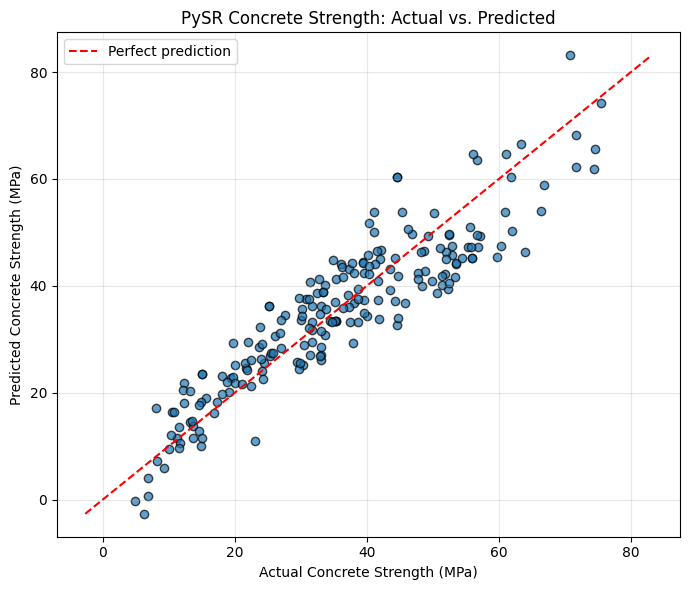

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    concrete_y_test,
    concrete_final_predictions,
    alpha=0.7,
    edgecolors="black"
)

minimum = min(
    concrete_y_test.min(),
    concrete_final_predictions.min()
)

maximum = max(
    concrete_y_test.max(),
    concrete_final_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Concrete Strength (MPa)")
plt.ylabel("Predicted Concrete Strength (MPa)")
plt.title("PySR Concrete Strength: Actual vs. Predicted")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "concrete_pysr_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Airfoil Self-Noise: PySR

In [ ]:
airfoil_df = pd.read_csv("airfoil.csv")

airfoil_df.columns = [
    "frequency",
    "attack_angle",
    "chord_length",
    "velocity",
    "displacement_thickness",
    "sound_pressure"
]

print(airfoil_df.head())
print("\nShape:", airfoil_df.shape)
print("\nMissing values:", airfoil_df.isna().sum().sum())

   frequency  attack_angle  chord_length  velocity  displacement_thickness  \
0        800           0.0        0.3048      71.3                0.002663   
1       1000           0.0        0.3048      71.3                0.002663   
2       1250           0.0        0.3048      71.3                0.002663   
3       1600           0.0        0.3048      71.3                0.002663   
4       2000           0.0        0.3048      71.3                0.002663   

   sound_pressure  
0         126.201  
1         125.201  
2         125.951  
3         127.591  
4         127.461  

Shape: (1503, 6)

Missing values: 0


In [ ]:
airfoil_X = airfoil_df.drop(columns=["sound_pressure"])
airfoil_y = airfoil_df["sound_pressure"]

In [ ]:
airfoil_X_train, airfoil_X_test, airfoil_y_train, airfoil_y_test = (
    train_test_split(
        airfoil_X,
        airfoil_y,
        test_size=0.20,
        random_state=42
    )
)

print("Training inputs:", airfoil_X_train.shape)
print("Testing inputs:", airfoil_X_test.shape)

Training inputs: (1202, 5)
Testing inputs: (301, 5)


In [ ]:
airfoil_model = PySRRegressor(
    niterations=500,

    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],

    unary_operators=[
        "square",
        "sqrt",
        "log"
    ],

    populations=20,
    population_size=50,
    maxsize=40,

    model_selection="accuracy",
    random_state=42,
    parallelism="multithreading",
    progress=True
)

In [ ]:
airfoil_model.fit(
    airfoil_X_train.to_numpy(),
    airfoil_y_train.to_numpy(),
    variable_names=airfoil_X.columns.tolist()
)

/usr/local/lib/python3.13/dist-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          124.87771   
	1         0.003210                           125.01107 - chord_length   
	2         0.091389                         132.30049 - log(frequency)   
	3         0.085685            (frequency * -0.000852968) + 127.323975   
	4         0.243392  128.70335 - sqrt(frequency * displacement_thic...   
	5         0.175956  127.58557 - ((chord_length * displacement_thic...   
	6         0.047473  128.55092 - (chord_length * ((displacement_thi...   
	7         0.039921  132.62465 - sqrt((frequency * displacement_thi...   
	8         0.031010  ((frequency * -24.550152) / ((velocity + squar...   
	9         0.069422  ((frequency / ((9.627149 / (displacement_thick...   
	10        0.043364  ((frequency / (frequency + (sqrt(velocity) / (...   
	11        0.035239  ((frequency / (square(velocity) + ((7.6793704 ...   
	12        0.008147  (((frequency / ((square(velocity) + frequency)...   
	13        0.075224  (((2.615075 / (frequency * chord_length)) + (f...   
	14        0.071620  (((frequency / ((sqrt(velocity) / (chord_lengt...   
	15        0.022504  (((frequency / ((4.9186945 / (displacement_thi...   
	16        0.130427  (((2.2797184 / (chord_length * frequency)) + (...   
	17        0.000969  (((2.2797184 / (chord_length * frequency)) + (...   
	18        0.001568  ((((12.333497 / (frequency * chord_length)) / ...   
	19        0.022173  (frequency * -0.00014857588) + ((((2.3438883 /...   
	20        0.047628  ((-4.7498484 / (frequency * displacement_thick...   
	21        0.010371  (-4.7498484 / ((frequency * displacement_thick...   
	22        0.027139  136.24767 + ((((11.367588 / log(displacement_t...   
	23        0.019658  ((((13.0870495 / log((displacement_thickness /...   
	24        0.009872  ((((14.344941 / log((displacement_thickness / ...   
	25        0.011997  ((((14.344941 / (frequency * chord_length)) / ...   
	26        0.008641  (((frequency / ((frequency + (2.3002949 / (dis...   
	27  >>>>  0.003404  ((((14.344941 / (frequency * chord_length)) / ...   
	
	         loss  complexity  
	0   46.915646           1  
	1   46.615444           3  
	2   42.544167           4  
	3   39.050587           5  
	4   30.614250           6  
	5   25.674799           7  
	6   23.349207           9  
	7   22.435442          10  
	8   21.086262          12  
	9   19.672073          13  
	10  18.837238          14  
	11  17.555328          16  
	12  17.271610          18  
	13  16.020033          19  
	14  14.912802          20  
	15  14.580948          21  
	16  12.797994          22  
	17  12.773204          24  
	18  12.753196          25  
	19  12.473534          26  
	20  11.340190          28  
	21  11.107391          30  
	22  10.810006          31  
	23  10.393243          33  
	24  10.190052          35  
	25  10.068536          36  
	26   9.981912          37  
	27   9.914178          39  
]

In [ ]:
airfoil_predictions = airfoil_model.predict(
    airfoil_X_test.to_numpy()
)

airfoil_mse = mean_squared_error(
    airfoil_y_test,
    airfoil_predictions
)

airfoil_rmse = airfoil_mse ** 0.5

airfoil_mae = mean_absolute_error(
    airfoil_y_test,
    airfoil_predictions
)

airfoil_r2 = r2_score(
    airfoil_y_test,
    airfoil_predictions
)

print("Selected equation:")
print(airfoil_model.sympy())

print("\nTest MSE:", airfoil_mse)
print("Test RMSE:", airfoil_rmse)
print("Test MAE:", airfoil_mae)
print("Test R²:", airfoil_r2)

Selected equation:
-36.989017*frequency/(frequency + (-195.3614*displacement_thickness**2*velocity + velocity)**2 + 128.70335 + 2.3002949/(chord_length*displacement_thickness)) + 136.76428 - 530.605266512997/(chord_length*frequency*log(195.3614*displacement_thickness/chord_length))

Test MSE: 9.224438513821564
Test RMSE: 3.0371760755381905
Test MAE: 2.3528911541263478
Test R²: 0.8158742446191578


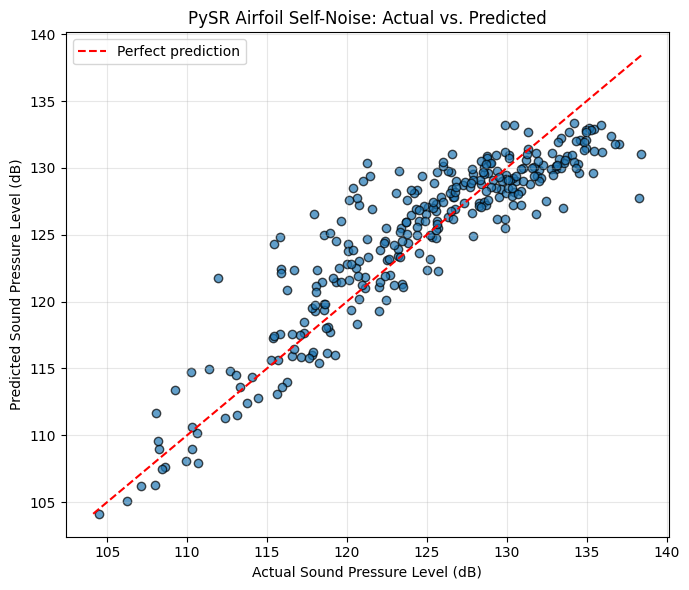

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    airfoil_y_test,
    airfoil_predictions,
    alpha=0.7,
    edgecolors="black"
)

minimum = min(
    airfoil_y_test.min(),
    airfoil_predictions.min()
)

maximum = max(
    airfoil_y_test.max(),
    airfoil_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Sound Pressure Level (dB)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("PySR Airfoil Self-Noise: Actual vs. Predicted")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "airfoil_pysr_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()